Device: cuda

[1/8] Loading data...
  Total: 1696 segments

[2/8] Train / Val / Test split...
  Split: train 1187 | val 254 | test 255
  Norm from train: SBP [97.6, 126.5] DBP [56.3, 73.5]

[3/8] Building model...
  Params: 192,578

[4/8] Training...
  Epoch  10 | Train: 0.02706 | Val: 0.03346 | Best: 0.02429
  Epoch  20 | Train: 0.02285 | Val: 0.02593 | Best: 0.02011
  Epoch  30 | Train: 0.01732 | Val: 0.01749 | Best: 0.01749
  Epoch  40 | Train: 0.01434 | Val: 0.01996 | Best: 0.01679
  Epoch  50 | Train: 0.01357 | Val: 0.01773 | Best: 0.01584
  Epoch  60 | Train: 0.01207 | Val: 0.01713 | Best: 0.01572
  Epoch  70 | Train: 0.01159 | Val: 0.01595 | Best: 0.01544
  Epoch  80 | Train: 0.01049 | Val: 0.01591 | Best: 0.01544

[5/8] BP evaluation...

  === Val BP Performance (N=254) ===
    SBP: MAE=3.24 | ME=+0.03±4.20 mmHg | r=0.6858
         ≤5: 75.6% | ≤10: 97.6% | ≤15: 100.0%
    DBP: MAE=1.34 | ME=+0.10±1.71 mmHg | r=0.7676
         ≤5: 99.6% | ≤10: 100.0% | ≤15: 100.0%
  [Saved] blan

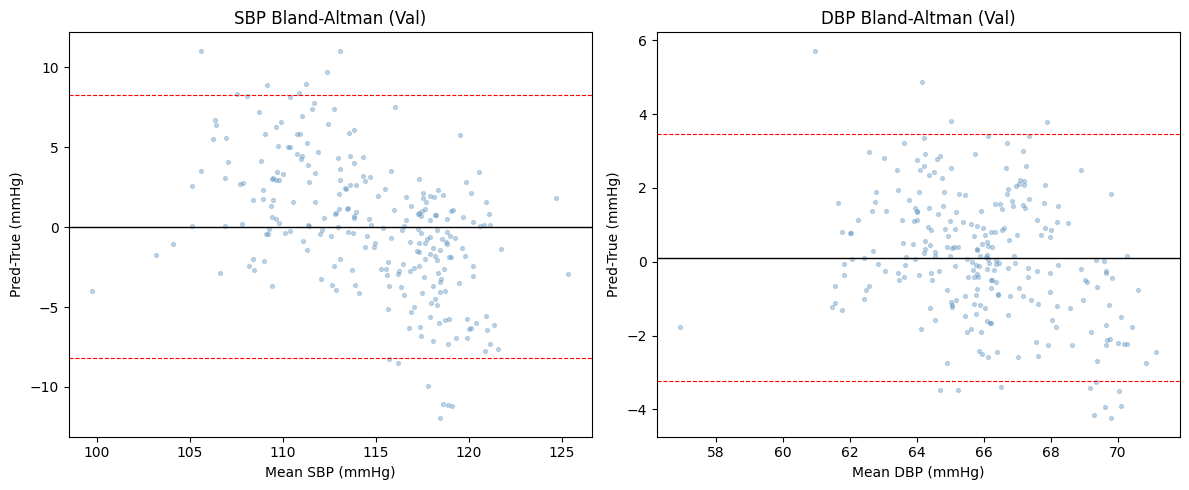


  === Test BP Performance (N=255) ===
    SBP: MAE=3.12 | ME=-0.27±4.08 mmHg | r=0.7000
         ≤5: 80.4% | ≤10: 98.4% | ≤15: 99.6%
    DBP: MAE=1.34 | ME=-0.03±1.69 mmHg | r=0.7885
         ≤5: 99.6% | ≤10: 100.0% | ≤15: 100.0%
  [Saved] bland_altman_test.png


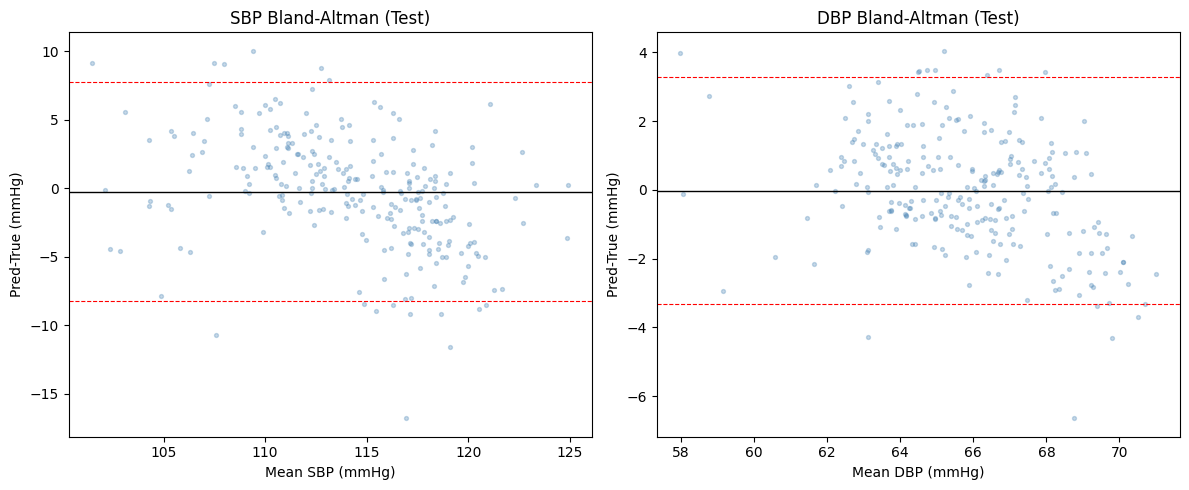


[6/8] Computing attributions on TEST set...
  Attribution 50/50

[7/8] Generating figures...

  --- Figure 1: Beat-aligned attribution ---
  [Saved] fig1_beat_aligned.png


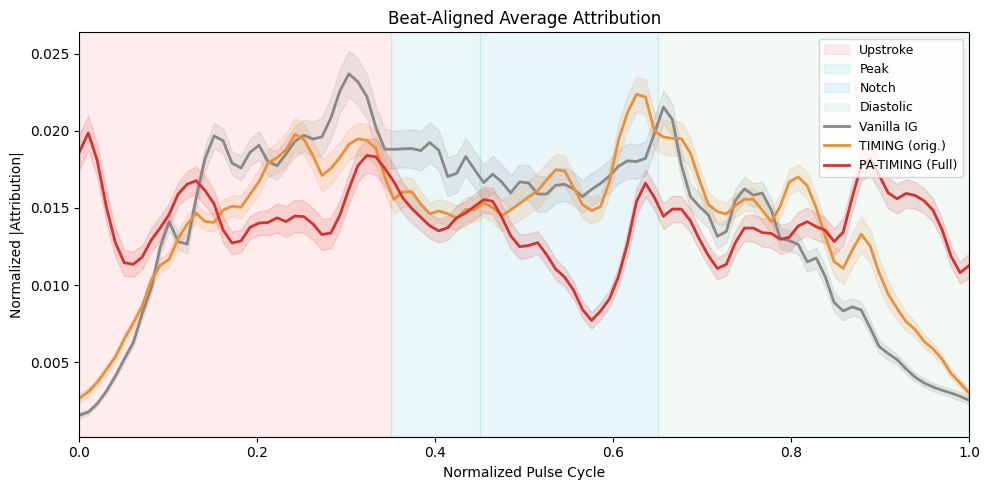


  --- Figure 2: Phase ratio boxplot ---
  [Saved] fig2_phase_ratio.png


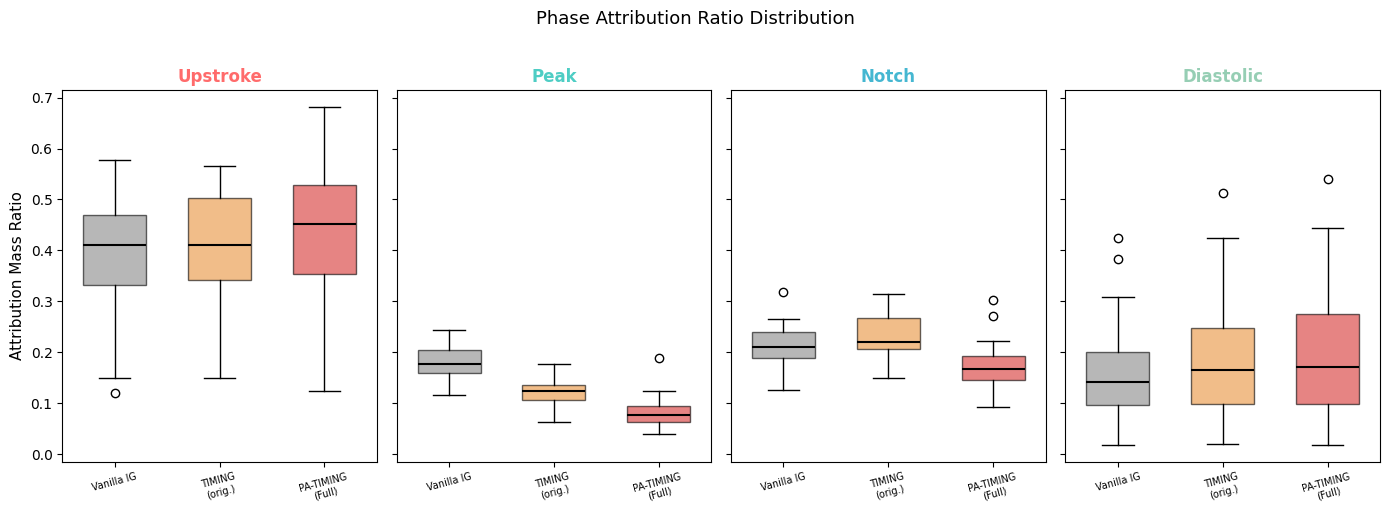


  === Phase Selectivity Entropy (lower = more selective) ===
  Method                      Mean H    Std H
  ---------------------------------------------
  Vanilla IG                  1.2643   0.0936
  TIMING (orig.)              1.2367   0.0900
  PA-TIMING (Full)            1.1487   0.1111

  --- Figure 3: Faithfulness curves ---

  === Faithfulness AUC ===
  Method                      Del AUC↑  Pres AUC↓
  ------------------------------------------------
  Vanilla IG                    0.0771     0.1433
  TIMING (orig.)                0.0576     0.1320
  PA-TIMING (Full)              0.0771     0.1141
  [Saved] fig3_faithfulness.png


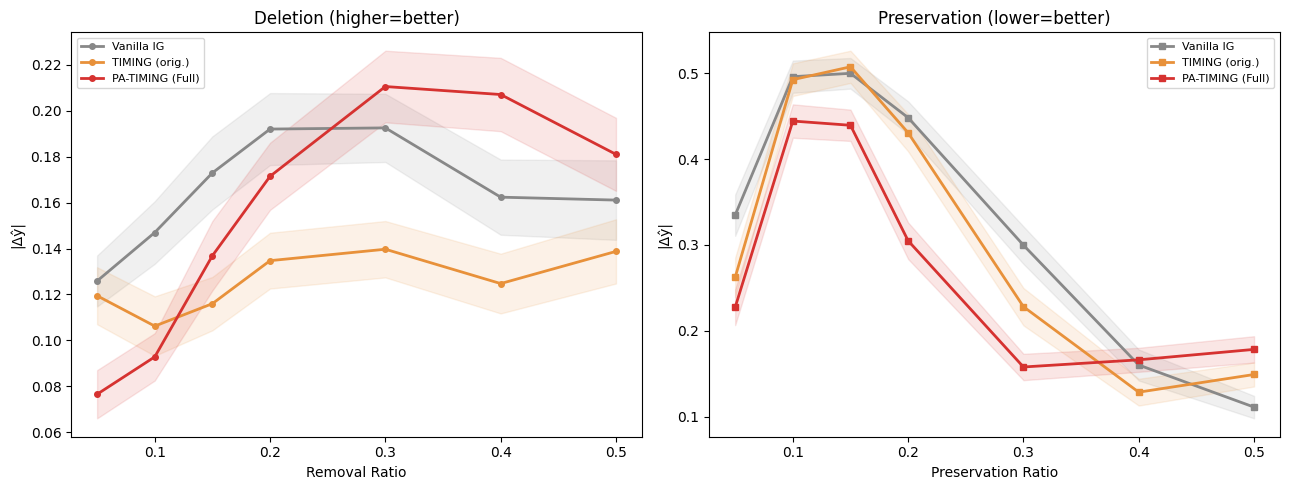


  --- Figure 4: Phase occlusion ---

  === Phase Occlusion ===
        Upstroke: 0.1778 ± 0.1318
            Peak: 0.1904 ± 0.0994
           Notch: 0.1186 ± 0.1123
       Diastolic: 0.1285 ± 0.1163
  [Saved] fig4_phase_occlusion.png


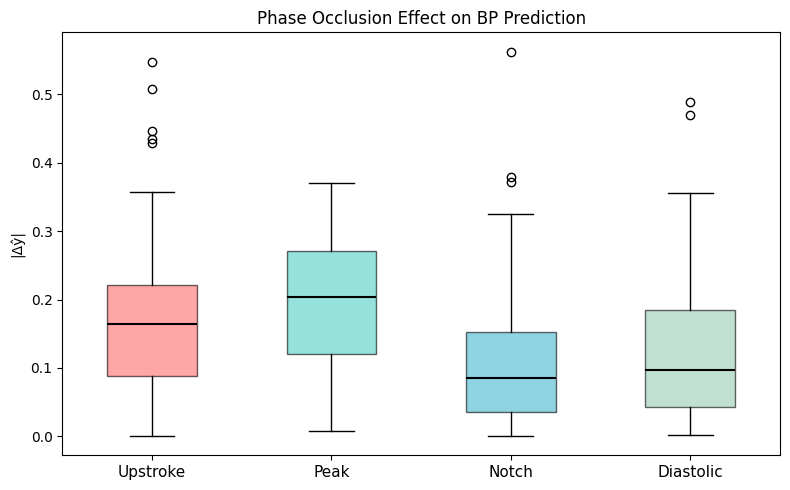


  --- Supplementary: Zoomed beats ---
  [Saved] supp_zoomed_beats.png


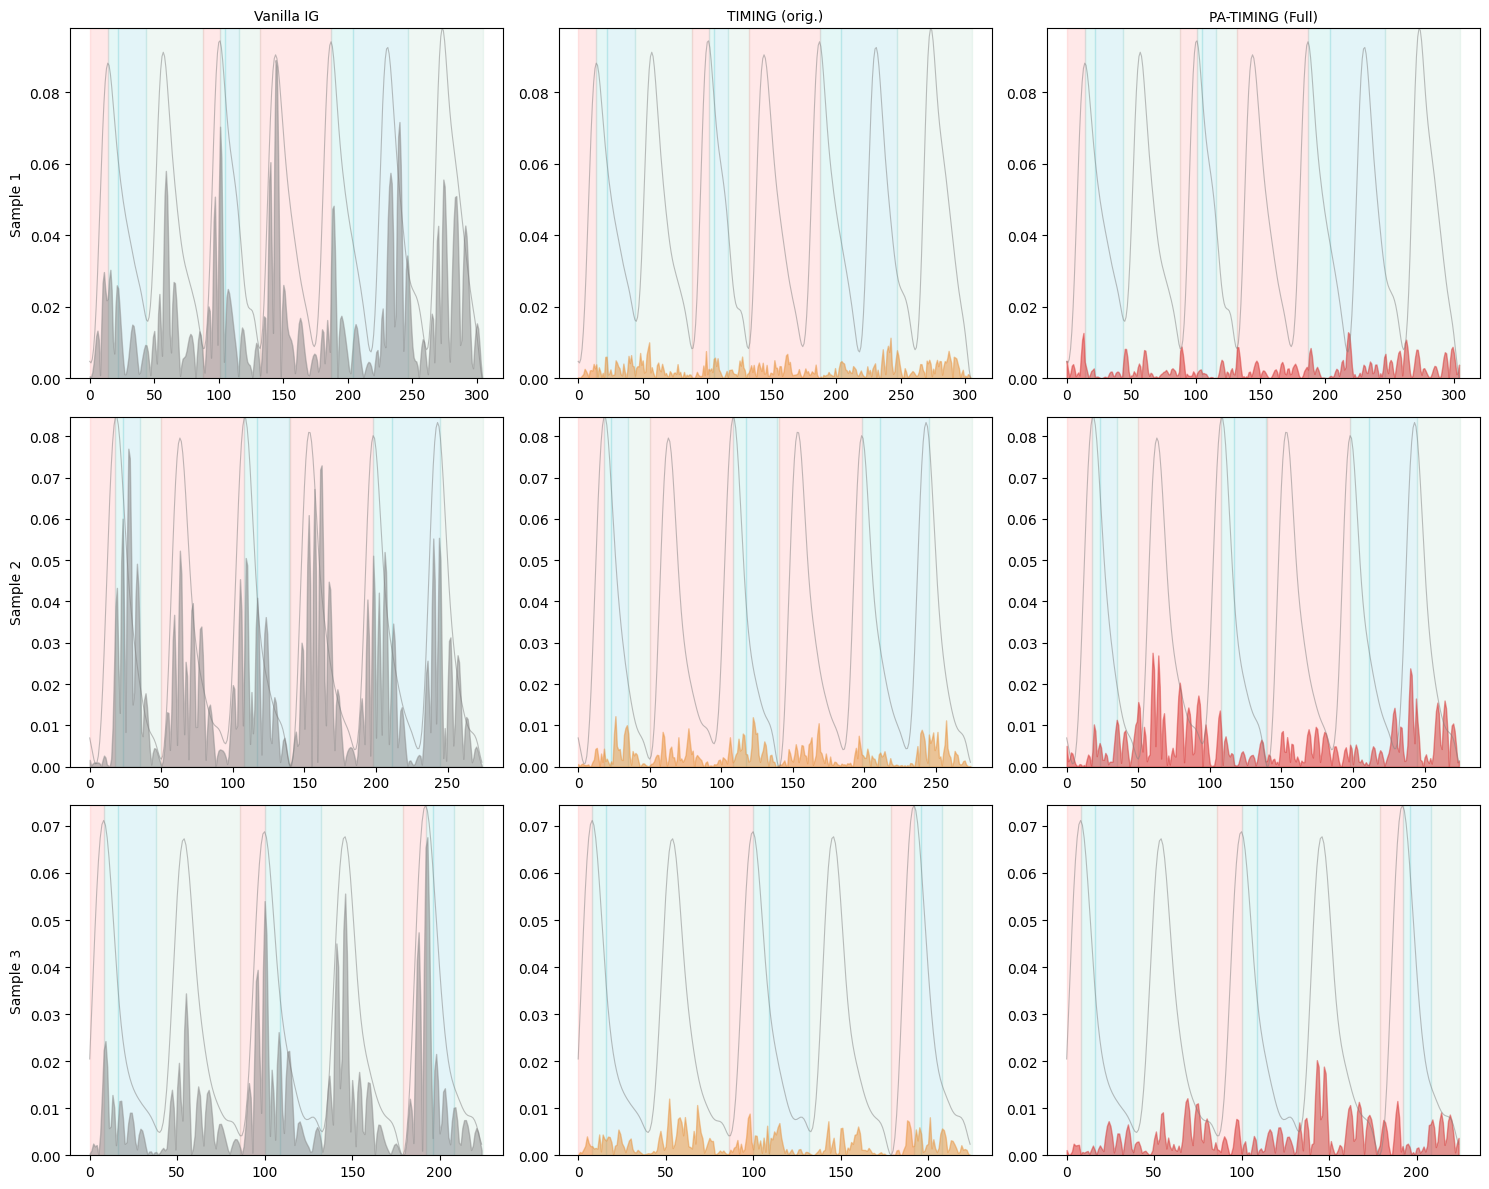


[8/8] All done!


In [ ]:
"""
PA-TIMING: Physiology-Aware Temporality-Aware Integrated Gradients
for PPG-based Blood Pressure Estimation
==========================================================
- Personalized model: segment-level train / val / test split
- BP regression training + test evaluation (MAE/ME/SD/r/BHS)
- Beat-aligned average attribution (Figure 1)
- Phase attribution ratio boxplot (Figure 2)
- Deletion / Preservation curves + AUC (Figure 3)
- Phase occlusion effect (Figure 4)
- Phase selectivity entropy
- Zoomed qualitative beat panel (Supplementary)
"""

import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# =====================================================
# Config
# =====================================================
PAD_LEN = 625
BATCH_SIZE = 32
EPOCHS = 80
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

R_MASKS = 32
M_STEPS = 64
P_KEEP = 0.6
G_PHASES = 4
PHASE_NAMES = ['Upstroke', 'Peak', 'Notch', 'Diastolic']
PHASE_COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
METHOD_COLORS = {
    'Vanilla IG': '#888888',
    'TIMING (orig.)': '#E8913A',
    'PA-TIMING (Full)': '#D63230',
}

BEAT_RESAMPLE = 100
N_ATTR_SAMPLES = 50
DELETION_RATIOS = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

MAT_PATH = "/content/drive/MyDrive/Colab Notebooks/MIMIC_S/p044036.mat"

# =====================================================
# 1) Cubic Resampling
# =====================================================
def cubic_resample(ppg, target_len=PAD_LEN):
    if len(ppg) < 4:
        return np.interp(
            np.linspace(0, 1, target_len),
            np.linspace(0, 1, len(ppg)), ppg
        ).astype(np.float32)
    try:
        f = interp1d(
            np.linspace(0, 1, len(ppg)), ppg,
            kind="cubic", bounds_error=False, fill_value="extrapolate",
        )
        return f(np.linspace(0, 1, target_len)).astype(np.float32)
    except Exception:
        return np.interp(
            np.linspace(0, 1, target_len),
            np.linspace(0, 1, len(ppg)), ppg
        ).astype(np.float32)


# =====================================================
# 2) Data Loading
# =====================================================
def load_data_from_mat(mat_path, segment_limit=None):
    segments, targets = [], []
    with h5py.File(mat_path, "r") as f:
        sw = f["Subj_Wins"]
        refs = sw["PPG_F"][0]
        sbps = sw["SegSBP"][0]
        dbps = sw["SegDBP"][0]
        total = min(len(refs), segment_limit) if segment_limit else len(refs)
        for i in range(total):
            ppg = f[refs[i]][()].squeeze().astype(np.float32)
            sbp = float(f[sbps[i]][()][0][0])
            dbp = float(f[dbps[i]][()][0][0])
            segments.append(ppg)
            targets.append([sbp, dbp])
    return segments, targets


# =====================================================
# 3) Segment-Level Random Split (personalized model)
# =====================================================
def random_split_segments(segments, targets, train_r=0.70, val_r=0.15, seed=42):
    """
    Segment 단위 랜덤 split → train / val / test.
    개인화 모델이므로 동일 피험자 데이터가 세 세트에 걸쳐도 무방.
    """
    n = len(segments)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(n)

    n_train = max(1, int(n * train_r))
    n_val = max(1, int(n * val_r))

    tr_idx = idx[:n_train]
    va_idx = idx[n_train:n_train + n_val]
    te_idx = idx[n_train + n_val:]

    def gather(ii):
        return [segments[i] for i in ii], [targets[i] for i in ii]

    tr, va, te = gather(tr_idx), gather(va_idx), gather(te_idx)
    print(f"  Split: train {len(tr[0])} | val {len(va[0])} | test {len(te[0])}")
    return tr, va, te


# =====================================================
# 4) Dataset
# =====================================================
class PPGDataset(Dataset):
    def __init__(self, segments, targets, norm_params=None):
        """
        norm_params: (sbp_min, sbp_max, dbp_min, dbp_max)
                     None이면 자체 계산 (train용),
                     주어지면 그대로 사용 (val/test용 — train 기준 정규화)
        """
        if norm_params is None:
            sbps = [t[0] for t in targets]
            dbps = [t[1] for t in targets]
            self.sbp_min, self.sbp_max = float(min(sbps)), float(max(sbps))
            self.dbp_min, self.dbp_max = float(min(dbps)), float(max(dbps))
        else:
            self.sbp_min, self.sbp_max, self.dbp_min, self.dbp_max = norm_params

        self.x_list, self.y_list = [], []
        self.raw_segments = segments

        sbp_den = max(self.sbp_max - self.sbp_min, 1.0)
        dbp_den = max(self.dbp_max - self.dbp_min, 1.0)

        for x, t in zip(segments, targets):
            x_interp = cubic_resample(x, PAD_LEN)
            y_norm = [
                (float(t[0]) - self.sbp_min) / sbp_den,
                (float(t[1]) - self.dbp_min) / dbp_den,
            ]
            self.x_list.append(x_interp)
            self.y_list.append(np.asarray(y_norm, dtype=np.float32))

    @property
    def norm_params(self):
        return (self.sbp_min, self.sbp_max, self.dbp_min, self.dbp_max)

    def __len__(self):
        return len(self.x_list)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.x_list[idx]).unsqueeze(0),
            torch.tensor(self.y_list[idx]),
        )

    def denorm_sbp(self, v):
        return v * (self.sbp_max - self.sbp_min) + self.sbp_min

    def denorm_dbp(self, v):
        return v * (self.dbp_max - self.dbp_min) + self.dbp_min


# =====================================================
# 5) Model
# =====================================================
class ResBlock1D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(ch)
        self.conv2 = nn.Conv1d(ch, ch, 7, padding=3)
        self.bn2 = nn.BatchNorm1d(ch)

    def forward(self, x):
        h = F.gelu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        return F.gelu(x + h)


class BPRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, 15, padding=7), nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32, 64, 7, padding=3), nn.BatchNorm1d(64), nn.GELU(),
        )
        self.blocks = nn.Sequential(ResBlock1D(64), ResBlock1D(64), ResBlock1D(64))
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.gap(h).squeeze(-1)
        return self.head(h)


# =====================================================
# 6) Pulse-Phase Segmentation
# =====================================================
def segment_pulse_phases(ppg_1d, fs=125):
    ppg = np.asarray(ppg_1d, dtype=np.float64)
    T = len(ppg)
    peaks, _ = find_peaks(ppg, distance=int(fs * 0.4), height=np.median(ppg))

    if len(peaks) < 2:
        q = T // G_PHASES
        return [(i * q, min((i + 1) * q, T)) for i in range(G_PHASES)]

    valleys = []
    for i in range(len(peaks) - 1):
        seg = ppg[peaks[i]:peaks[i + 1]]
        valleys.append(peaks[i] + np.argmin(seg))
    valleys = [max(0, peaks[0] - int(fs * 0.15))] + valleys + \
              [min(T - 1, peaks[-1] + int(fs * 0.3))]

    phases = []
    for bi in range(len(peaks)):
        onset = valleys[bi] if bi < len(valleys) else peaks[bi] - int(fs * 0.1)
        pk = peaks[bi]
        offset = valleys[bi + 1] if (bi + 1) < len(valleys) else min(pk + int(fs * 0.5), T - 1)
        onset, offset = max(0, onset), min(T - 1, offset)
        bl = offset - onset
        if bl < 8:
            continue
        pe = min(pk + max(1, int(bl * 0.1)), offset)
        ne = min(pk + max(2, int(bl * 0.35)), offset)
        phases.append((onset, pk))
        phases.append((pk, pe))
        phases.append((pe, ne))
        phases.append((ne, offset))

    if len(phases) == 0:
        q = T // G_PHASES
        return [(i * q, min((i + 1) * q, T)) for i in range(G_PHASES)]
    return phases


def get_beat_boundaries(ppg_1d, fs=125):
    ppg = np.asarray(ppg_1d, dtype=np.float64)
    T = len(ppg)
    peaks, _ = find_peaks(ppg, distance=int(fs * 0.4), height=np.median(ppg))
    if len(peaks) < 2:
        return [(0, T)]
    valleys = []
    for i in range(len(peaks) - 1):
        seg = ppg[peaks[i]:peaks[i + 1]]
        valleys.append(peaks[i] + np.argmin(seg))
    valleys = [max(0, peaks[0] - int(fs * 0.15))] + valleys + \
              [min(T - 1, peaks[-1] + int(fs * 0.3))]
    beats = [(valleys[i], valleys[i + 1]) for i in range(len(valleys) - 1)
             if valleys[i + 1] - valleys[i] >= 8]
    return beats if beats else [(0, T)]


# =====================================================
# 7) Template Baseline
# =====================================================
def build_template_baseline(ppg_list, target_len=PAD_LEN, max_beats=50):
    resampled = []
    for ppg in ppg_list[:max_beats]:
        r = cubic_resample(ppg, target_len)
        if np.std(r) < 1e-6:
            continue
        resampled.append(r)
    if len(resampled) == 0:
        return np.zeros(target_len, dtype=np.float32)
    return np.mean(resampled, axis=0).astype(np.float32)


# =====================================================
# 8) Attribution Methods
# =====================================================
class PATIMING:
    def __init__(self, model, R=R_MASKS, M=M_STEPS, p=P_KEEP, target_idx=0):
        self.model, self.R, self.M, self.p = model, R, M, p
        self.target_idx = target_idx

    def attribute(self, x, baseline_np):
        self.model.eval()
        device = x.device
        T = x.shape[-1]
        x_np = x.squeeze().cpu().numpy()
        phases = segment_pulse_phases(x_np)
        bl_t = torch.tensor(baseline_np, device=device).float().view(1, 1, -1)
        G = len(phases)
        acc = torch.zeros(1, 1, T, device=device)
        for r in range(self.R):
            z = torch.bernoulli(torch.full((G,), self.p, device=device))
            mask = torch.zeros(1, 1, T, device=device)
            for g, (s, e) in enumerate(phases):
                mask[0, 0, s:e] = z[g]
            b_r = mask * x + (1 - mask) * bl_t
            ig = torch.zeros_like(x)
            for m in range(1, self.M + 1):
                xa = (b_r + (m / self.M) * (x - b_r)).detach().requires_grad_(True)
                self.model(xa)[0, self.target_idx].backward()
                ig += xa.grad
            acc += (x - b_r) * (ig / self.M)
        return (acc / self.R).squeeze().cpu().numpy()


class VanillaIG:
    def __init__(self, model, M=64, target_idx=0):
        self.model, self.M, self.target_idx = model, M, target_idx

    def attribute(self, x):
        self.model.eval()
        bl = torch.zeros_like(x)
        ig = torch.zeros_like(x)
        for m in range(1, self.M + 1):
            xa = (bl + (m / self.M) * (x - bl)).detach().requires_grad_(True)
            self.model(xa)[0, self.target_idx].backward()
            ig += xa.grad
        return ((x - bl) * (ig / self.M)).squeeze().detach().cpu().numpy()


class OriginalTIMING:
    def __init__(self, model, R=32, M=64, p=0.6, target_idx=0):
        self.model, self.R, self.M, self.p = model, R, M, p
        self.target_idx = target_idx

    def attribute(self, x):
        self.model.eval()
        device, T = x.device, x.shape[-1]
        bl = torch.zeros_like(x)
        acc = torch.zeros_like(x)
        for r in range(self.R):
            mask = torch.bernoulli(torch.full((1, 1, T), self.p, device=device))
            b_r = mask * x + (1 - mask) * bl
            ig = torch.zeros_like(x)
            for m in range(1, self.M + 1):
                xa = (b_r + (m / self.M) * (x - b_r)).detach().requires_grad_(True)
                self.model(xa)[0, self.target_idx].backward()
                ig += xa.grad
            acc += (x - b_r) * (ig / self.M)
        return (acc / self.R).squeeze().detach().cpu().numpy()


# =====================================================
# 9) Training
# =====================================================
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    best_val = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x), y)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())
        scheduler.step()

        model.eval()
        vl = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                vl.append(criterion(model(x), y).item())

        tl, vl_m = np.mean(losses), np.mean(vl)
        if vl_m < best_val:
            best_val = vl_m
            torch.save(model.state_dict(), "best_bp_model.pt")
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | Train: {tl:.5f} | Val: {vl_m:.5f} | Best: {best_val:.5f}")

    model.load_state_dict(torch.load("best_bp_model.pt", weights_only=True))


# =====================================================
# 10) BP Prediction Evaluation (on TEST set)
# =====================================================
def evaluate_bp(model, loader, ds, split_name="Test"):
    model.eval()
    sp, st, dp, dt = [], [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            pred = model(x).cpu().numpy()
            y = y.numpy()
            for i in range(len(y)):
                sp.append(ds.denorm_sbp(pred[i, 0]))
                dp.append(ds.denorm_dbp(pred[i, 1]))
                st.append(ds.denorm_sbp(y[i, 0]))
                dt.append(ds.denorm_dbp(y[i, 1]))

    sp, st = np.array(sp), np.array(st)
    dp, dt = np.array(dp), np.array(dt)

    def _metrics(pred, true, name):
        err = pred - true
        mae = np.mean(np.abs(err))
        me, sd = np.mean(err), np.std(err)
        r, _ = pearsonr(pred, true)
        pct5 = np.mean(np.abs(err) <= 5) * 100
        pct10 = np.mean(np.abs(err) <= 10) * 100
        pct15 = np.mean(np.abs(err) <= 15) * 100
        print(f"    {name}: MAE={mae:.2f} | ME={me:+.2f}±{sd:.2f} mmHg | r={r:.4f}")
        print(f"         ≤5: {pct5:.1f}% | ≤10: {pct10:.1f}% | ≤15: {pct15:.1f}%")
        return mae, me, sd, r

    print(f"\n  === {split_name} BP Performance (N={len(sp)}) ===")
    sbp_m = _metrics(sp, st, "SBP")
    dbp_m = _metrics(dp, dt, "DBP")

    # Bland-Altman
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, p, t, nm in [(axes[0], sp, st, 'SBP'), (axes[1], dp, dt, 'DBP')]:
        mn = (p + t) / 2
        df = p - t
        md, sd_ = np.mean(df), np.std(df)
        ax.scatter(mn, df, alpha=0.3, s=8, c='steelblue')
        ax.axhline(md, color='k', linewidth=1)
        ax.axhline(md + 1.96 * sd_, color='r', ls='--', lw=0.8)
        ax.axhline(md - 1.96 * sd_, color='r', ls='--', lw=0.8)
        ax.set_xlabel(f'Mean {nm} (mmHg)'); ax.set_ylabel(f'Pred-True (mmHg)')
        ax.set_title(f'{nm} Bland-Altman ({split_name})')
    plt.tight_layout()
    plt.savefig(f"bland_altman_{split_name.lower()}.png", dpi=150, bbox_inches='tight')
    print(f"  [Saved] bland_altman_{split_name.lower()}.png")
    plt.show()

    return sbp_m, dbp_m


# =====================================================
# 11) Compute Attributions (on TEST set)
# =====================================================
def compute_all_attributions(model, dataset, baseline_np,
                             n_samples=N_ATTR_SAMPLES, target_idx=0):
    methods = {
        'Vanilla IG': VanillaIG(model, M=M_STEPS, target_idx=target_idx),
        'TIMING (orig.)': OriginalTIMING(model, R=R_MASKS, M=M_STEPS,
                                          p=P_KEEP, target_idx=target_idx),
        'PA-TIMING (Full)': PATIMING(model, R=R_MASKS, M=M_STEPS,
                                      p=P_KEEP, target_idx=target_idx),
    }
    results = {n: [] for n in methods}
    indices = np.random.choice(len(dataset),
                               size=min(n_samples, len(dataset)), replace=False)
    for ci, idx in enumerate(indices):
        x, _ = dataset[idx]
        x = x.unsqueeze(0).to(DEVICE)
        x_np = x.squeeze().cpu().numpy()
        print(f"\r  Attribution {ci + 1}/{len(indices)}", end="")
        for name, meth in methods.items():
            if name == 'PA-TIMING (Full)':
                attr = meth.attribute(x, baseline_np)
            else:
                attr = meth.attribute(x)
            results[name].append((x_np, attr))
    print()
    return results


# =====================================================
# 12) Figure 1: Beat-Aligned Average Attribution
# =====================================================
def fig1_beat_aligned_attribution(attr_results, save_path="fig1_beat_aligned.png"):
    fig, ax = plt.subplots(figsize=(10, 5))
    phase_bounds = [0, 0.35, 0.45, 0.65, 1.0]
    for g in range(G_PHASES):
        ax.axvspan(phase_bounds[g], phase_bounds[g + 1], alpha=0.12,
                   color=PHASE_COLORS[g], label=PHASE_NAMES[g])
    t_axis = np.linspace(0, 1, BEAT_RESAMPLE)

    for name, pairs in attr_results.items():
        all_beats = []
        for x_np, attr in pairs:
            beats = get_beat_boundaries(x_np)
            aa = np.abs(attr)
            for (s, e) in beats:
                if e - s < 8:
                    continue
                ba = aa[s:e]
                total = np.sum(ba) + 1e-12
                rs = np.interp(np.linspace(0, 1, BEAT_RESAMPLE),
                               np.linspace(0, 1, len(ba)), ba / total)
                all_beats.append(rs)
        if not all_beats:
            continue
        arr = np.array(all_beats)
        mu = np.mean(arr, axis=0)
        se = np.std(arr, axis=0) / np.sqrt(len(arr))
        c = METHOD_COLORS.get(name, '#333')
        ax.plot(t_axis, mu, color=c, lw=2, label=name)
        ax.fill_between(t_axis, mu - se, mu + se, color=c, alpha=0.15)

    ax.set_xlabel('Normalized Pulse Cycle'); ax.set_ylabel('Normalized |Attribution|')
    ax.set_title('Beat-Aligned Average Attribution'); ax.set_xlim(0, 1)
    h, l = ax.get_legend_handles_labels()
    seen, uh, ul = set(), [], []
    for hi, li in zip(h, l):
        if li not in seen: seen.add(li); uh.append(hi); ul.append(li)
    ax.legend(uh, ul, fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"  [Saved] {save_path}"); plt.show()


# =====================================================
# 13) Figure 2: Phase Attribution Ratio Boxplot
# =====================================================
def fig2_phase_ratio_boxplot(attr_results, save_path="fig2_phase_ratio.png"):
    method_names = list(attr_results.keys())
    ratio_data = {n: {g: [] for g in range(G_PHASES)} for n in method_names}

    for name, pairs in attr_results.items():
        for x_np, attr in pairs:
            phases = segment_pulse_phases(x_np)
            aa = np.abs(attr)
            total = np.sum(aa) + 1e-12
            ps = [0.0] * G_PHASES
            for gi, (s, e) in enumerate(phases):
                ps[gi % G_PHASES] += np.sum(aa[s:e])
            for g in range(G_PHASES):
                ratio_data[name][g].append(ps[g] / total)

    fig, axes = plt.subplots(1, G_PHASES, figsize=(14, 5), sharey=True)
    for g in range(G_PHASES):
        ax = axes[g]
        data = [ratio_data[n][g] for n in method_names]
        bp = ax.boxplot(data, patch_artist=True, widths=0.6,
                        medianprops=dict(color='black', lw=1.5))
        for patch, c in zip(bp['boxes'],
                            [METHOD_COLORS.get(n, '#999') for n in method_names]):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        ax.set_title(PHASE_NAMES[g], fontsize=12, fontweight='bold',
                     color=PHASE_COLORS[g])
        ax.set_xticks(range(1, len(method_names) + 1))
        ax.set_xticklabels([n.replace(' (', '\n(') for n in method_names],
                           fontsize=7, rotation=15)
        if g == 0:
            ax.set_ylabel('Attribution Mass Ratio', fontsize=11)

    fig.suptitle('Phase Attribution Ratio Distribution', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"  [Saved] {save_path}"); plt.show()
    return ratio_data


# =====================================================
# 14) Phase Selectivity Entropy
# =====================================================
def compute_phase_entropy(ratio_data):
    print("\n  === Phase Selectivity Entropy (lower = more selective) ===")
    print(f"  {'Method':<25s} {'Mean H':>8s} {'Std H':>8s}")
    print("  " + "-" * 45)
    for name in ratio_data:
        Hs = []
        n = len(ratio_data[name][0])
        for i in range(n):
            r = np.array([ratio_data[name][g][i] for g in range(G_PHASES)]) + 1e-12
            r /= r.sum()
            Hs.append(-np.sum(r * np.log(r)))
        print(f"  {name:<25s} {np.mean(Hs):>8.4f} {np.std(Hs):>8.4f}")


# =====================================================
# 15) Figure 3: Deletion / Preservation Curves
# =====================================================
def fig3_deletion_preservation(model, attr_results, baseline_np,
                                save_path="fig3_faithfulness.png"):
    ratios = DELETION_RATIOS
    del_c = {n: [] for n in attr_results}
    pres_c = {n: [] for n in attr_results}

    for name, pairs in attr_results.items():
        for x_np, attr in pairs:
            x_t = torch.tensor(x_np, device=DEVICE).float().view(1, 1, -1)
            bl_t = torch.tensor(baseline_np, device=DEVICE).float().view(1, 1, -1)
            T = len(x_np)
            with torch.no_grad():
                orig = model(x_t)[0, 0].item()
            d_row, p_row = [], []
            for kr in ratios:
                k = max(1, int(T * kr))
                top = np.argsort(np.abs(attr))[::-1][:k].copy()
                # deletion
                xd = x_t.clone(); xd[0, 0, top] = bl_t[0, 0, top]
                with torch.no_grad():
                    d_row.append(abs(orig - model(xd)[0, 0].item()))
                # preservation
                xp = bl_t.clone(); xp[0, 0, top] = x_t[0, 0, top]
                with torch.no_grad():
                    p_row.append(abs(orig - model(xp)[0, 0].item()))
            del_c[name].append(d_row)
            pres_c[name].append(p_row)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
    print("\n  === Faithfulness AUC ===")
    print(f"  {'Method':<25s} {'Del AUC↑':>10s} {'Pres AUC↓':>10s}")
    print("  " + "-" * 48)

    for name in attr_results:
        c = METHOD_COLORS.get(name, '#333')
        dm = np.mean(del_c[name], axis=0)
        ds = np.std(del_c[name], axis=0) / np.sqrt(len(del_c[name]))
        pm = np.mean(pres_c[name], axis=0)
        ps = np.std(pres_c[name], axis=0) / np.sqrt(len(pres_c[name]))
        a1.plot(ratios, dm, 'o-', color=c, label=name, lw=2, ms=4)
        a1.fill_between(ratios, dm - ds, dm + ds, color=c, alpha=0.12)
        a2.plot(ratios, pm, 's-', color=c, label=name, lw=2, ms=4)
        a2.fill_between(ratios, pm - ps, pm + ps, color=c, alpha=0.12)
        da = np.trapz(dm, ratios); pa = np.trapz(pm, ratios)
        print(f"  {name:<25s} {da:>10.4f} {pa:>10.4f}")

    a1.set_xlabel('Removal Ratio'); a1.set_ylabel('|Δŷ|')
    a1.set_title('Deletion (higher=better)'); a1.legend(fontsize=8)
    a2.set_xlabel('Preservation Ratio'); a2.set_ylabel('|Δŷ|')
    a2.set_title('Preservation (lower=better)'); a2.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"  [Saved] {save_path}"); plt.show()


# =====================================================
# 16) Figure 4: Phase Occlusion Effect
# =====================================================
def fig4_phase_occlusion(model, dataset, baseline_np, n_samples=50,
                          save_path="fig4_phase_occlusion.png", target_idx=0):
    bl_t = torch.tensor(baseline_np, device=DEVICE).float().view(1, 1, -1)
    occ = {g: [] for g in range(G_PHASES)}
    indices = np.random.choice(len(dataset), min(n_samples, len(dataset)), replace=False)

    for idx in indices:
        x, _ = dataset[idx]
        x = x.unsqueeze(0).to(DEVICE)
        x_np = x.squeeze().cpu().numpy()
        phases = segment_pulse_phases(x_np)
        with torch.no_grad():
            orig = model(x)[0, target_idx].item()
        pi = {g: [] for g in range(G_PHASES)}
        for gi, (s, e) in enumerate(phases):
            pi[gi % G_PHASES].extend(range(s, e))
        for g in range(G_PHASES):
            if not pi[g]:
                continue
            xo = x.clone()
            ia = np.array(pi[g])
            xo[0, 0, ia] = bl_t[0, 0, ia]
            with torch.no_grad():
                occ[g].append(abs(orig - model(xo)[0, target_idx].item()))

    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot([occ[g] for g in range(G_PHASES)], patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=1.5))
    for patch, c in zip(bp['boxes'], PHASE_COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_xticklabels(PHASE_NAMES, fontsize=11)
    ax.set_ylabel('|Δŷ|'); ax.set_title('Phase Occlusion Effect on BP Prediction')
    print("\n  === Phase Occlusion ===")
    for g in range(G_PHASES):
        if occ[g]:
            print(f"    {PHASE_NAMES[g]:>12s}: {np.mean(occ[g]):.4f} ± {np.std(occ[g]):.4f}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"  [Saved] {save_path}"); plt.show()
    return occ


# =====================================================
# 17) Supplementary: Zoomed Beat Panel
# =====================================================
def supp_zoomed_beats(attr_results, n_examples=3, n_beats=3,
                      save_path="supp_zoomed_beats.png"):
    mns = list(attr_results.keys())
    nm = len(mns)
    fig, axes = plt.subplots(n_examples, nm, figsize=(5 * nm, 4 * n_examples))
    if n_examples == 1:
        axes = axes[np.newaxis, :]

    for ei in range(min(n_examples, len(attr_results[mns[0]]))):
        x_np, _ = attr_results[mns[0]][ei]
        beats = get_beat_boundaries(x_np)[:n_beats]
        if not beats:
            continue
        s0, e0 = beats[0][0], beats[-1][1]

        ymax = max(np.max(np.abs(attr_results[n][ei][1][s0:e0])) for n in mns) * 1.1
        for mi, name in enumerate(mns):
            ax = axes[ei, mi]
            _, attr = attr_results[name][ei]
            sx, sa = x_np[s0:e0], np.abs(attr[s0:e0])
            phases = segment_pulse_phases(x_np)
            for gi, (s, e) in enumerate(phases):
                sr, er = s - s0, e - s0
                if sr < 0 or er <= 0 or sr >= len(sx):
                    continue
                ax.axvspan(sr, min(er, len(sx)), alpha=0.15,
                           color=PHASE_COLORS[gi % G_PHASES])
            wn = (sx - sx.min()) / (sx.max() - sx.min() + 1e-12) * ymax
            ax.plot(wn, color='gray', alpha=0.5, lw=0.8)
            c = METHOD_COLORS.get(name, '#333')
            ax.fill_between(range(len(sa)), sa, alpha=0.5, color=c)
            ax.set_ylim(0, ymax)
            if ei == 0: ax.set_title(name, fontsize=10)
            if mi == 0: ax.set_ylabel(f'Sample {ei + 1}')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"  [Saved] {save_path}"); plt.show()


# =====================================================
# 18) Main
# =====================================================
def main():
    print(f"Device: {DEVICE}")

    # ── 1. Load ──
    print("\n[1/8] Loading data...")
    segments, targets = load_data_from_mat(MAT_PATH)
    print(f"  Total: {len(segments)} segments")

    # ── 2. Segment-level random split ──
    print("\n[2/8] Train / Val / Test split...")
    (tr_seg, tr_tgt), (va_seg, va_tgt), (te_seg, te_tgt) = \
        random_split_segments(segments, targets)

    train_ds = PPGDataset(tr_seg, tr_tgt)
    val_ds = PPGDataset(va_seg, va_tgt, norm_params=train_ds.norm_params)
    test_ds = PPGDataset(te_seg, te_tgt, norm_params=train_ds.norm_params)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    print(f"  Norm from train: SBP [{train_ds.sbp_min:.1f}, {train_ds.sbp_max:.1f}] "
          f"DBP [{train_ds.dbp_min:.1f}, {train_ds.dbp_max:.1f}]")

    # ── 3. Model ──
    print("\n[3/8] Building model...")
    model = BPRegressor().to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # ── 4. Train ──
    print("\n[4/8] Training...")
    train_model(model, train_loader, val_loader)

    # ── 5. BP evaluation on val + test ──
    print("\n[5/8] BP evaluation...")
    evaluate_bp(model, val_loader, val_ds, split_name="Val")
    evaluate_bp(model, test_loader, test_ds, split_name="Test")

    # ── 6. Attributions (on test set) ──
    print("\n[6/8] Computing attributions on TEST set...")
    baseline_np = build_template_baseline(train_ds.raw_segments)  # baseline from train
    attr_results = compute_all_attributions(
        model, test_ds, baseline_np, n_samples=min(N_ATTR_SAMPLES, len(test_ds)))

    # ── 7. Figures ──
    print("\n[7/8] Generating figures...")

    print("\n  --- Figure 1: Beat-aligned attribution ---")
    fig1_beat_aligned_attribution(attr_results)

    print("\n  --- Figure 2: Phase ratio boxplot ---")
    ratio_data = fig2_phase_ratio_boxplot(attr_results)
    compute_phase_entropy(ratio_data)

    print("\n  --- Figure 3: Faithfulness curves ---")
    fig3_deletion_preservation(model, attr_results, baseline_np)

    print("\n  --- Figure 4: Phase occlusion ---")
    fig4_phase_occlusion(model, test_ds, baseline_np)

    print("\n  --- Supplementary: Zoomed beats ---")
    supp_zoomed_beats(attr_results)

    # ── 8. Done ──
    print("\n[8/8] All done!")


if __name__ == "__main__":
    main()